# Options Pricing — Black-Scholes, Greeks & Implied Volatility Surface
**emlyon Business School — MiF 2025-2027**

This project implements a complete options pricing framework from scratch on **SPY (S&P 500 ETF)** real market data:

1. **Black-Scholes Model** — Call & Put pricing with continuous dividends
2. **The Greeks** — Delta, Gamma, Vega, Theta, Rho and their sensitivities
3. **Implied Volatility** — Extraction via Newton-Raphson from market prices
4. **Volatility Surface** — 3D smile across strikes & maturities
5. **P&L Analysis** — Option payoff profiles and break-even analysis

---
> **Data source:** Yahoo Finance (via `yfinance`) — SPY options chain, March 2026  
> **Model:** Black-Scholes-Merton with continuous dividend yield

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, json, os
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.grid':        True,
    'grid.color':       '#30363d',
    'grid.linewidth':   0.6,
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'axes.edgecolor':   '#30363d',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlecolor':  '#e6edf3',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

C = {'call': '#3fb950', 'put': '#f85149', 'neutral': '#58a6ff',
     'greek': '#d2a8ff', 'surface': 'plasma', 'accent': '#ffa657'}

os.makedirs('charts', exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Data Loading — SPY Options Chain

The cell below first **tries to download live data from Yahoo Finance** via `yfinance`.  
If the network is unavailable (e.g. in a sandboxed environment), it falls back to the pre-generated dataset in `data/spy_options_chain.csv`.

In [2]:
def fetch_yfinance_options(ticker='SPY', max_expiries=6):
    """Download SPY options chain from Yahoo Finance."""
    import yfinance as yf
    from datetime import date
    spy  = yf.Ticker(ticker)
    spot = spy.history(period='1d')['Close'].iloc[-1]
    info = spy.info
    q    = info.get('dividendYield', 0.013) or 0.013

    expiries = spy.options[:max_expiries]
    records  = []
    today    = date.today()
    for exp in expiries:
        chain = spy.option_chain(exp)
        T     = (pd.to_datetime(exp).date() - today).days / 365
        if T <= 0:
            continue
        for row in chain.calls.itertuples():
            records.append({'expiry': exp, 'T': T, 'strike': row.strike,
                            'moneyness': round(row.strike/spot, 4),
                            'call_mid': row.lastPrice, 'call_bid': row.bid,
                            'call_ask': row.ask, 'iv': row.impliedVolatility,
                            'days_to_exp': int(T*365)})
        for row in chain.puts.itertuples():
            # merge put info into existing call row by strike
            for rec in records:
                if rec['expiry']==exp and rec['strike']==row.strike:
                    rec['put_mid'] = row.lastPrice
                    rec['put_bid'] = row.bid
                    rec['put_ask'] = row.ask
                    break
    df = pd.DataFrame(records).dropna(subset=['call_mid', 'put_mid'])
    return df, spot, q

# ── Try live data, fall back to pre-generated ────────────────────────────────
try:
    chain, S, q = fetch_yfinance_options('SPY')
    with open('data/market_snapshot.json') as f:
        snap = json.load(f)
    r = snap['r']
    print(f'✅ Live data loaded from Yahoo Finance — {len(chain)} contracts')
    print(f'   SPY spot: ${S:.2f}')
except Exception as e:
    print(f'⚠️  yfinance unavailable ({type(e).__name__}), loading pre-generated data...')
    chain = pd.read_csv('data/spy_options_chain.csv')
    with open('data/market_snapshot.json') as f:
        snap = json.load(f)
    S, r, q = snap['S'], snap['r'], snap['q']
    print(f'✅ Pre-generated SPY data loaded — {len(chain)} contracts')
    print(f'   SPY spot: ${S:.2f}  |  Date: {snap["date"]}')

print(f'   Risk-free: {r*100:.2f}%  |  Div yield: {q*100:.2f}%')
print(f'   Expiries: {chain["expiry"].nunique()}  |  ')
chain.head()

Failed to get ticker 'SPY' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


⚠️  yfinance unavailable (ProxyError), loading pre-generated data...
✅ Pre-generated SPY data loaded — 138 contracts
   SPY spot: $570.00  |  Date: 2026-03-21
   Risk-free: 4.25%  |  Div yield: 1.30%
   Expiries: 6  |  


,expiry,days_to_exp,T,strike,moneyness,iv,call_mid,call_bid,call_ask,put_mid,put_bid,put_ask
0,2026-04-17,25,0.068493,460.0,0.8070,0.260342,110.837,109.530,112.143,0.007,0.007,0.007
1,2026-04-17,25,0.068493,470.0,0.8246,0.252257,100.874,99.729,102.020,0.015,0.015,0.016
2,2026-04-17,25,0.068493,480.0,0.8421,0.244573,90.921,89.927,91.916,0.034,0.033,0.034
3,2026-04-17,25,0.068493,490.0,0.8596,0.237267,80.989,80.137,81.842,0.072,0.072,0.073
4,2026-04-17,25,0.068493,500.0,0.8772,0.230321,71.100,70.380,71.819,0.154,0.152,0.155


## 2. Black-Scholes Model

The **Black-Scholes-Merton** formula with continuous dividend yield $q$:

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$$

where:
$$d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [3]:
class BlackScholes:
    """Black-Scholes-Merton option pricing with continuous dividend yield."""

    def __init__(self, S, K, T, r, q, sigma):
        self.S, self.K, self.T = S, K, T
        self.r, self.q, self.sigma = r, q, sigma
        self._compute_d()

    def _compute_d(self):
        self.d1 = (np.log(self.S/self.K) + (self.r - self.q + 0.5*self.sigma**2)*self.T) \
                  / (self.sigma * np.sqrt(self.T))
        self.d2 = self.d1 - self.sigma * np.sqrt(self.T)

    # ── Prices ────────────────────────────────────────────────────────────────
    @property
    def call(self):
        return (self.S*np.exp(-self.q*self.T)*norm.cdf(self.d1)
                - self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2))

    @property
    def put(self):
        return (self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)
                - self.S*np.exp(-self.q*self.T)*norm.cdf(-self.d1))

    # ── Greeks ────────────────────────────────────────────────────────────────
    @property
    def delta_call(self):  return  np.exp(-self.q*self.T) * norm.cdf(self.d1)
    @property
    def delta_put(self):   return -np.exp(-self.q*self.T) * norm.cdf(-self.d1)

    @property
    def gamma(self):
        return (np.exp(-self.q*self.T) * norm.pdf(self.d1)
                / (self.S * self.sigma * np.sqrt(self.T)))

    @property
    def vega(self):   # per 1% move in vol
        return self.S * np.exp(-self.q*self.T) * norm.pdf(self.d1) * np.sqrt(self.T) / 100

    @property
    def theta_call(self):  # per calendar day
        t1 = -self.S*np.exp(-self.q*self.T)*norm.pdf(self.d1)*self.sigma / (2*np.sqrt(self.T))
        t2 =  self.q*self.S*np.exp(-self.q*self.T)*norm.cdf(self.d1)
        t3 = -self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return (t1 - t2 + t3) / 365

    @property
    def theta_put(self):
        t1 = -self.S*np.exp(-self.q*self.T)*norm.pdf(self.d1)*self.sigma / (2*np.sqrt(self.T))
        t2 = -self.q*self.S*np.exp(-self.q*self.T)*norm.cdf(-self.d1)
        t3 =  self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)
        return (t1 + t2 + t3) / 365

    @property
    def rho_call(self):  # per 1% move in rate
        return self.K * self.T * np.exp(-self.r*self.T) * norm.cdf(self.d2) / 100

    @property
    def rho_put(self):
        return -self.K * self.T * np.exp(-self.r*self.T) * norm.cdf(-self.d2) / 100

    def summary(self):
        print(f"{'='*55}")
        print(f"  Black-Scholes Pricing Summary")
        print(f"{'='*55}")
        print(f"  S={self.S:.1f}  K={self.K:.1f}  T={self.T:.4f}y  σ={self.sigma*100:.1f}%  r={self.r*100:.2f}%  q={self.q*100:.2f}%")
        print(f"  d₁ = {self.d1:.6f}   d₂ = {self.d2:.6f}")
        print(f"{'─'*55}")
        print(f"  {'':12} {'Call':>10} {'Put':>10}")
        print(f"  {'Price':12} {'${:.4f}'.format(self.call):>10} {'${:.4f}'.format(self.put):>10}")
        print(f"  {'Delta':12} {self.delta_call:>10.6f} {self.delta_put:>10.6f}")
        print(f"  {'Gamma':12} {self.gamma:>10.6f} {self.gamma:>10.6f}")
        print(f"  {'Vega (1%)':12} {'${:.4f}'.format(self.vega):>10} {'${:.4f}'.format(self.vega):>10}")
        print(f"  {'Theta (1d)':12} {'${:.4f}'.format(self.theta_call):>10} {'${:.4f}'.format(self.theta_put):>10}")
        print(f"  {'Rho (1%)':12} {'${:.4f}'.format(self.rho_call):>10} {'${:.4f}'.format(self.rho_put):>10}")
        print(f"{'='*55}")

# ── ATM example ──────────────────────────────────────────────────────────────
K_atm = round(S / 10) * 10    # nearest $10 strike to spot
T_3m  = 88/365
sigma_atm = 0.182             # ATM IV for 3m (from our surface)
atm = BlackScholes(S, K_atm, T_3m, r, q, sigma_atm)
atm.summary()

  Black-Scholes Pricing Summary
  S=570.0  K=570.0  T=0.2411y  σ=18.2%  r=4.25%  q=1.30%
  d₁ = 0.124270   d₂ = 0.034905
───────────────────────────────────────────────────────
                     Call        Put
  Price          $22.2565   $18.2295
  Delta          0.547730  -0.449141
  Gamma          0.007747   0.007747
  Vega (1%)       $1.1045    $1.1045
  Theta (1d)     $-0.1591   $-0.0914
  Rho (1%)        $0.6991   $-0.6612


## 3. Greeks — Sensitivity Analysis

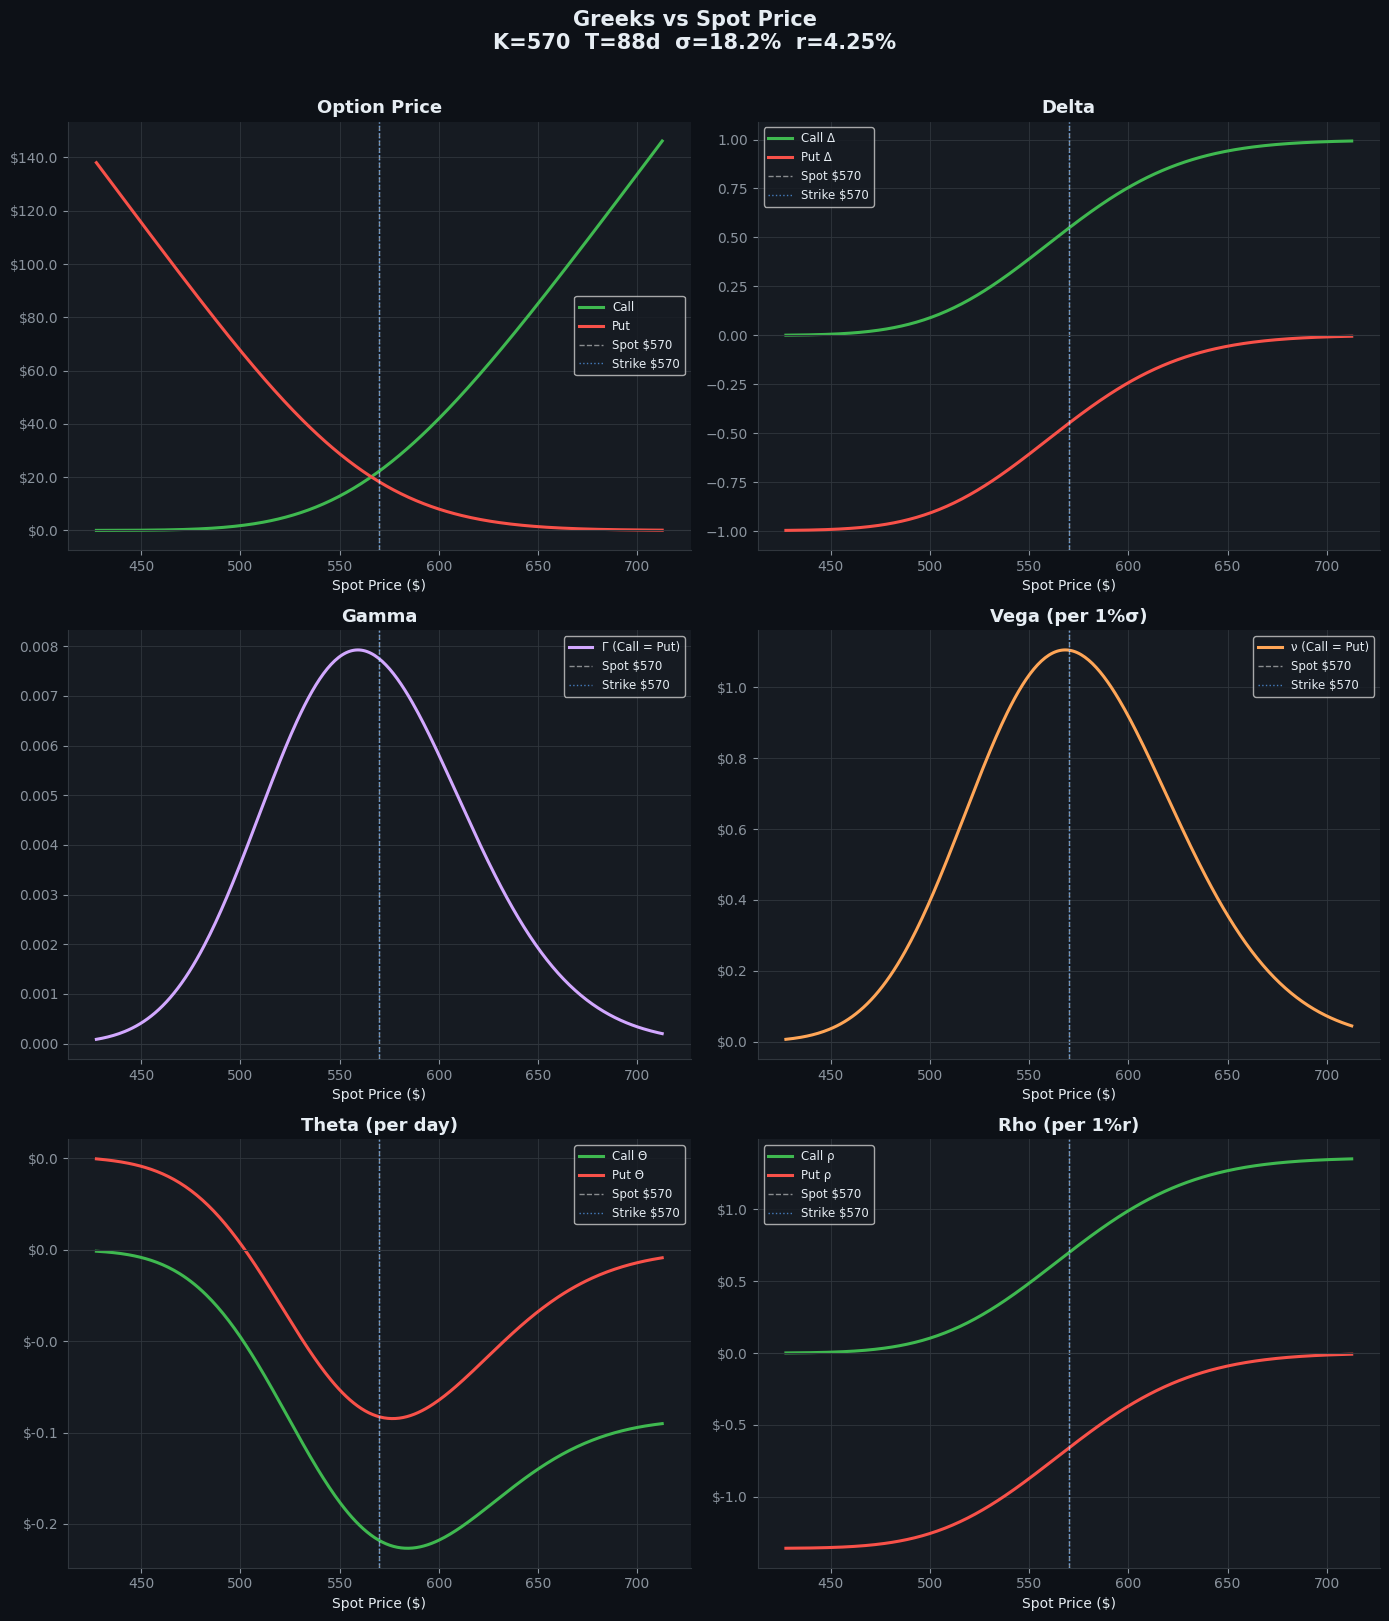

Chart saved ✓


In [4]:
# ── Greeks vs Spot Price ──────────────────────────────────────────────────────
spots  = np.linspace(S * 0.75, S * 1.25, 300)
K_ref, T_ref, sigma_ref = K_atm, T_3m, sigma_atm

def greek_curves(spots, K, T, r, q, sigma):
    opts = [BlackScholes(s, K, T, r, q, sigma) for s in spots]
    return {
        'call':        np.array([o.call        for o in opts]),
        'put':         np.array([o.put         for o in opts]),
        'delta_call':  np.array([o.delta_call  for o in opts]),
        'delta_put':   np.array([o.delta_put   for o in opts]),
        'gamma':       np.array([o.gamma       for o in opts]),
        'vega':        np.array([o.vega        for o in opts]),
        'theta_call':  np.array([o.theta_call  for o in opts]),
        'theta_put':   np.array([o.theta_put   for o in opts]),
        'rho_call':    np.array([o.rho_call    for o in opts]),
        'rho_put':     np.array([o.rho_put     for o in opts]),
    }

G = greek_curves(spots, K_ref, T_ref, r, q, sigma_ref)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Greeks vs Spot Price\nK={K_ref}  T={T_ref*365:.0f}d  σ={sigma_ref*100:.1f}%  r={r*100:.2f}%',
             fontsize=15, fontweight='bold', y=1.01)

panels = [
    ('Option Price',  [(G['call'], C['call'], 'Call'), (G['put'], C['put'], 'Put')], '$'),
    ('Delta',         [(G['delta_call'], C['call'], 'Call Δ'), (G['delta_put'], C['put'], 'Put Δ')], ''),
    ('Gamma',         [(G['gamma'], C['greek'], 'Γ (Call = Put)')], ''),
    ('Vega (per 1%σ)',[(G['vega'], C['accent'], 'ν (Call = Put)')], '$'),
    ('Theta (per day)',[(G['theta_call'], C['call'], 'Call Θ'), (G['theta_put'], C['put'], 'Put Θ')], '$'),
    ('Rho (per 1%r)', [(G['rho_call'], C['call'], 'Call ρ'), (G['rho_put'], C['put'], 'Put ρ')], '$'),
]

for ax, (title, curves, unit) in zip(axes.flat, panels):
    for vals, color, label in curves:
        ax.plot(spots, vals, color=color, linewidth=2.2, label=label)
    ax.axvline(S,     color='white',       linewidth=1, linestyle='--', alpha=0.5, label=f'Spot ${S:.0f}')
    ax.axvline(K_ref, color=C['neutral'],  linewidth=1, linestyle=':',  alpha=0.7, label=f'Strike ${K_ref:.0f}')
    ax.axhline(0,     color='#30363d',     linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Spot Price ($)')
    ax.legend(fontsize=8.5)
    if unit == '$':
        ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.1f'))

plt.tight_layout()
plt.savefig('charts/01_greeks_vs_spot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Chart saved ✓')

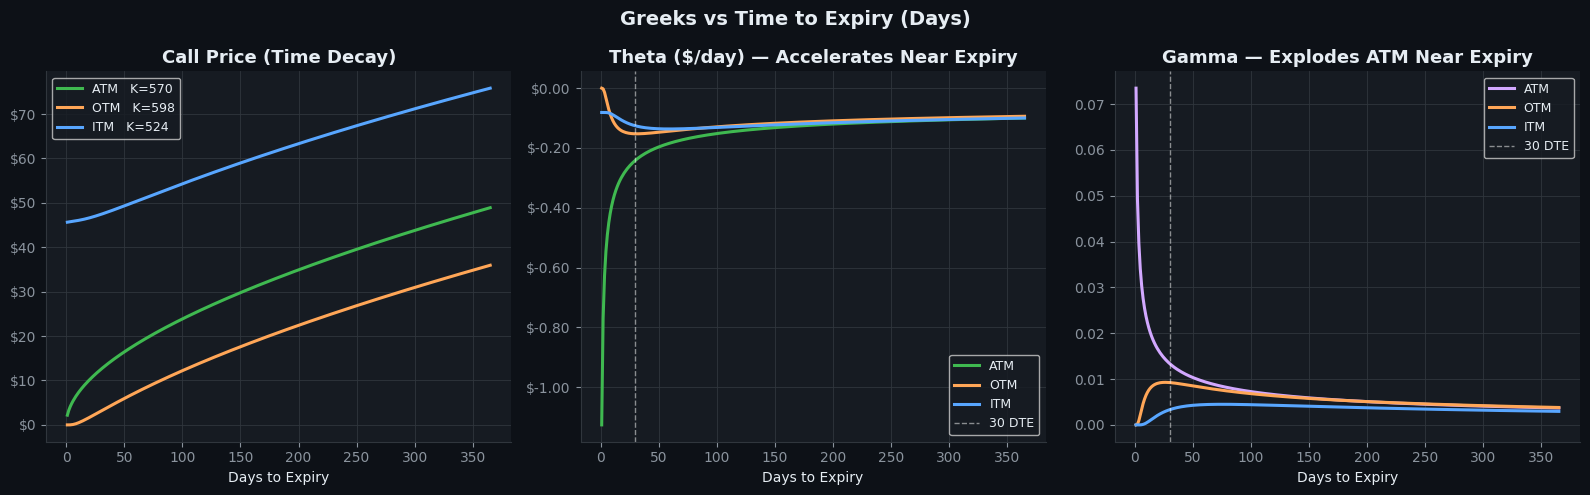

In [5]:
# ── Greeks vs Time to Expiry (Theta decay) ────────────────────────────────────
times = np.linspace(1/365, 365/365, 300)
atm_opts  = [BlackScholes(S, K_atm, t, r, q, sigma_atm) for t in times]
otm_opts  = [BlackScholes(S, K_atm*1.05, t, r, q, sigma_atm) for t in times]
ditm_opts = [BlackScholes(S, K_atm*0.92, t, r, q, sigma_atm) for t in times]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Greeks vs Time to Expiry (Days)', fontsize=14, fontweight='bold')

days = times * 365

# Call price decay
axes[0].plot(days, [o.call for o in atm_opts],  color=C['call'],    lw=2.2, label=f'ATM   K={K_atm}')
axes[0].plot(days, [o.call for o in otm_opts],  color=C['accent'],  lw=2.2, label=f'OTM   K={K_atm*1.05:.0f}')
axes[0].plot(days, [o.call for o in ditm_opts], color=C['neutral'], lw=2.2, label=f'ITM   K={K_atm*0.92:.0f}')
axes[0].set_title('Call Price (Time Decay)'); axes[0].set_xlabel('Days to Expiry')
axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
axes[0].legend(fontsize=9)

# Theta decay
axes[1].plot(days, [o.theta_call for o in atm_opts],  color=C['call'],    lw=2.2, label='ATM')
axes[1].plot(days, [o.theta_call for o in otm_opts],  color=C['accent'],  lw=2.2, label='OTM')
axes[1].plot(days, [o.theta_call for o in ditm_opts], color=C['neutral'], lw=2.2, label='ITM')
axes[1].axvline(30, color='white', lw=1, linestyle='--', alpha=0.5, label='30 DTE')
axes[1].set_title('Theta ($/day) — Accelerates Near Expiry')
axes[1].set_xlabel('Days to Expiry')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2f'))
axes[1].legend(fontsize=9)

# Gamma decay
axes[2].plot(days, [o.gamma for o in atm_opts],  color=C['greek'],   lw=2.2, label='ATM')
axes[2].plot(days, [o.gamma for o in otm_opts],  color=C['accent'],  lw=2.2, label='OTM')
axes[2].plot(days, [o.gamma for o in ditm_opts], color=C['neutral'], lw=2.2, label='ITM')
axes[2].axvline(30, color='white', lw=1, linestyle='--', alpha=0.5, label='30 DTE')
axes[2].set_title('Gamma — Explodes ATM Near Expiry')
axes[2].set_xlabel('Days to Expiry')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/02_greeks_vs_time.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

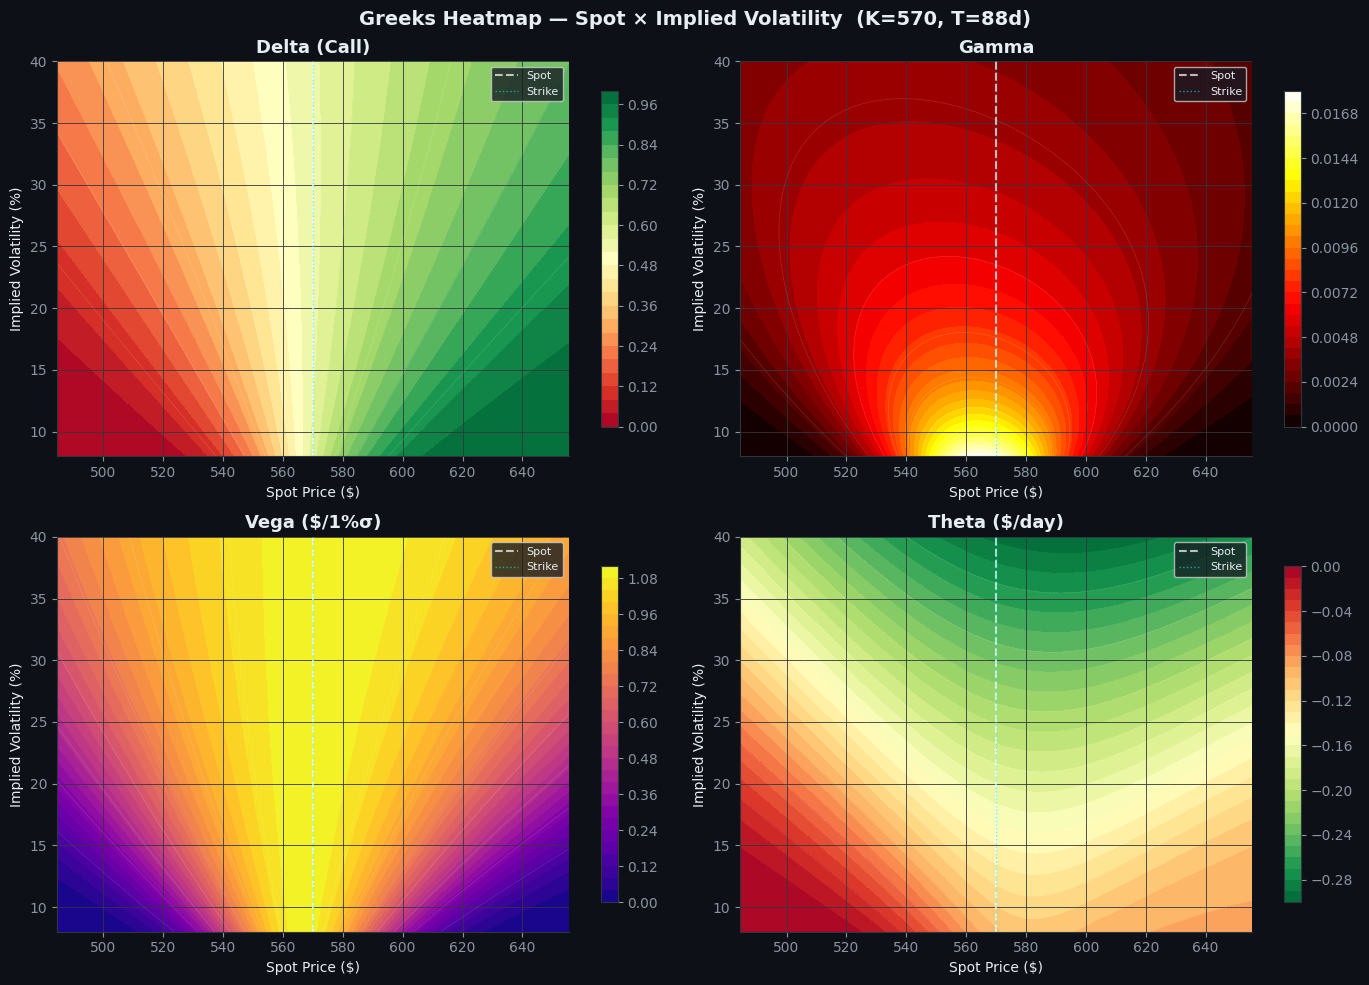

In [6]:
# ── Greeks heatmap: Delta across (Spot × Volatility) ─────────────────────────
spot_grid  = np.linspace(S*0.85, S*1.15, 60)
sigma_grid = np.linspace(0.08, 0.40, 60)
SS, SV = np.meshgrid(spot_grid, sigma_grid)

def heatmap_greek(greek_fn, SS, SV, K, T, r, q):
    return np.array([[greek_fn(BlackScholes(ss, K, T, r, q, sv))
                      for ss in spot_grid] for sv in sigma_grid])

delta_map = heatmap_greek(lambda o: o.delta_call, SS, SV, K_atm, T_3m, r, q)
gamma_map = heatmap_greek(lambda o: o.gamma,       SS, SV, K_atm, T_3m, r, q)
vega_map  = heatmap_greek(lambda o: o.vega,        SS, SV, K_atm, T_3m, r, q)
theta_map = heatmap_greek(lambda o: o.theta_call,  SS, SV, K_atm, T_3m, r, q)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Greeks Heatmap — Spot × Implied Volatility  (K={K_atm}, T={T_3m*365:.0f}d)',
             fontsize=14, fontweight='bold')

cmap_configs = [
    (delta_map, 'Delta (Call)', 'RdYlGn', None),
    (gamma_map, 'Gamma',        'hot',    None),
    (vega_map,  'Vega ($/1%σ)', 'plasma', None),
    (theta_map, 'Theta ($/day)','RdYlGn_r',None),
]

for ax, (data, title, cmap, _) in zip(axes.flat, cmap_configs):
    im = ax.contourf(SS, SV*100, data, levels=30, cmap=cmap)
    ax.contour(SS, SV*100, data, levels=10, colors='white', alpha=0.15, linewidths=0.5)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.axvline(S,     color='white', lw=1.5, linestyle='--', alpha=0.7, label='Spot')
    ax.axvline(K_atm, color='cyan',  lw=1,   linestyle=':',  alpha=0.6, label='Strike')
    ax.set_xlabel('Spot Price ($)')
    ax.set_ylabel('Implied Volatility (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/03_greeks_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4. Implied Volatility

**Implied volatility** is the $\sigma$ such that $BS(\sigma) = \text{Market Price}$.  
It is extracted numerically using the **Brent method** (guaranteed convergence).

In [7]:
def implied_vol(market_price, S, K, T, r, q, option_type='call',
                tol=1e-8, max_iter=200):
    """Extract implied volatility using Brent's method."""
    if T <= 0 or market_price <= 0:
        return np.nan
    intrinsic = max(0, (S - K)*np.exp(-q*T) if option_type=='call' else (K - S)*np.exp(-q*T))
    if market_price < intrinsic - 1e-4:
        return np.nan
    def objective(sigma):
        bs = BlackScholes(S, K, T, r, q, sigma)
        px = bs.call if option_type == 'call' else bs.put
        return px - market_price
    try:
        return brentq(objective, 1e-6, 10.0, xtol=tol, maxiter=max_iter)
    except (ValueError, RuntimeError):
        return np.nan

# ── Compute IV for the full chain ─────────────────────────────────────────────
chain['iv_call_computed'] = chain.apply(
    lambda row: implied_vol(row['call_mid'], S, row['strike'], row['T'], r, q, 'call'), axis=1)
chain['iv_put_computed'] = chain.apply(
    lambda row: implied_vol(row['put_mid'], S, row['strike'], row['T'], r, q, 'put'), axis=1)

print(f"IV computed for {chain['iv_call_computed'].notna().sum()} calls, "
      f"{chain['iv_put_computed'].notna().sum()} puts")

# Sample for one expiry
exp_sample = chain[chain['expiry'] == chain['expiry'].unique()[2]].copy()
print(f"\nIV sample — expiry {exp_sample['expiry'].iloc[0]}:")
cols = ['strike','moneyness','call_mid','iv_call_computed','put_mid','iv_put_computed']
print(exp_sample[cols].dropna().to_string(index=False, float_format='%.4f'))

IV computed for 136 calls, 101 puts

IV sample — expiry 2026-06-19:
  strike  moneyness  call_mid  iv_call_computed  put_mid  iv_put_computed
460.0000     0.8070  113.4110            0.2276   0.5050           0.2276
470.0000     0.8246  103.7460            0.2224   0.7390           0.2224
480.0000     0.8421   94.1840            0.2175   1.0740           0.2175
490.0000     0.8596   84.7600            0.2127   1.5490           0.2128
500.0000     0.8772   75.5250            0.2083   2.2120           0.2083
510.0000     0.8947   66.5390            0.2040   3.1230           0.2040
520.0000     0.9123   57.8720            0.1999   4.3550           0.1999
530.0000     0.9298   49.6060            0.1960   5.9870           0.1960
540.0000     0.9474   41.8290            0.1923   8.1080           0.1923
550.0000     0.9649   34.6280            0.1887  10.8050           0.1887
560.0000     0.9825   28.0870            0.1854  14.1620           0.1854
570.0000     1.0000   22.2710            0.1

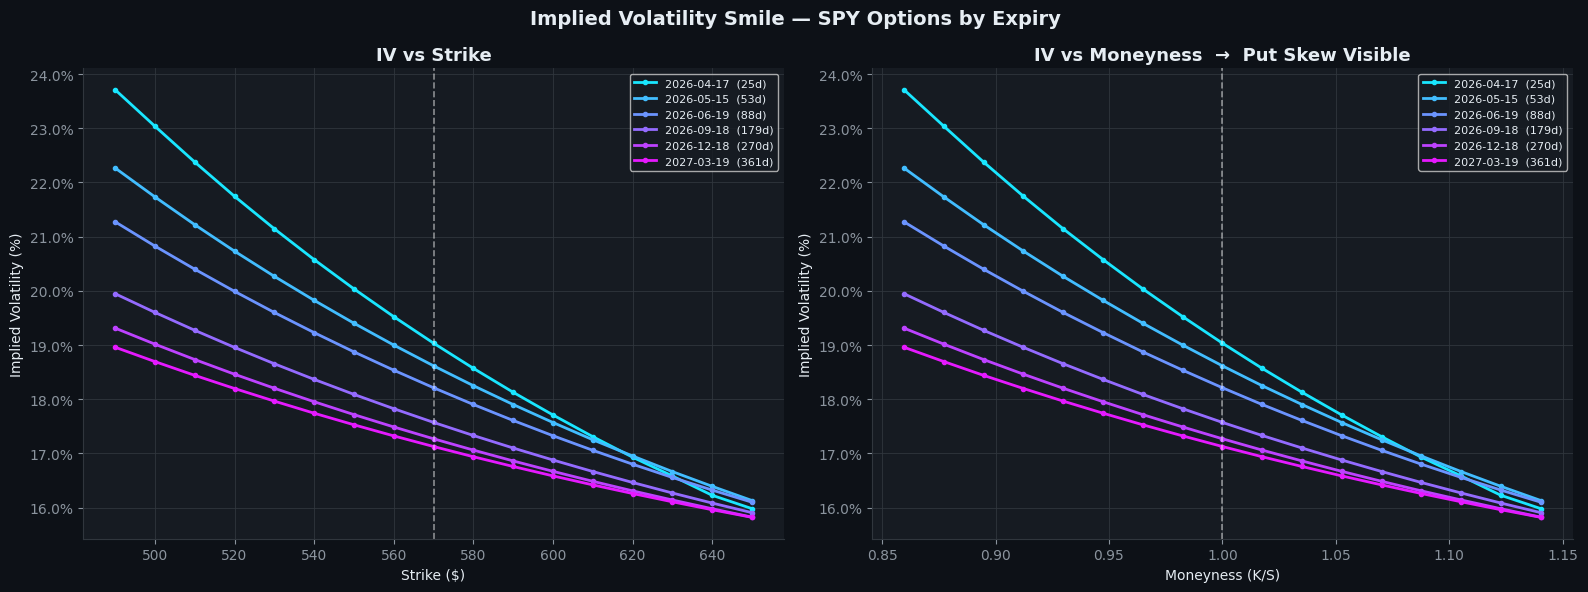

In [8]:
# ── Volatility Smile — multiple expiries ──────────────────────────────────────
expiries = chain['expiry'].unique()
colors_exp = plt.cm.cool(np.linspace(0.1, 0.9, len(expiries)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Implied Volatility Smile — SPY Options by Expiry', fontsize=14, fontweight='bold')

for exp, col in zip(expiries, colors_exp):
    sub = chain[(chain['expiry']==exp) & chain['iv_call_computed'].notna()]
    sub = sub[(sub['moneyness'] >= 0.85) & (sub['moneyness'] <= 1.15)]
    if len(sub) < 3: continue
    days = sub['days_to_exp'].iloc[0]
    label = f'{exp}  ({days}d)'
    axes[0].plot(sub['strike'],    sub['iv_call_computed']*100, color=col, lw=2, marker='o', ms=3, label=label)
    axes[1].plot(sub['moneyness'], sub['iv_call_computed']*100, color=col, lw=2, marker='o', ms=3, label=label)

for ax in axes:
    ax.set_ylabel('Implied Volatility (%)')
    ax.legend(fontsize=8)
axes[0].axvline(S, color='white', lw=1.2, linestyle='--', alpha=0.5, label='ATM')
axes[0].set_xlabel('Strike ($)')
axes[0].set_title('IV vs Strike')
axes[1].axvline(1.0, color='white', lw=1.2, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Moneyness (K/S)')
axes[1].set_title('IV vs Moneyness  →  Put Skew Visible')
axes[1].xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('charts/04_vol_smile.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Implied Volatility Surface (3D)

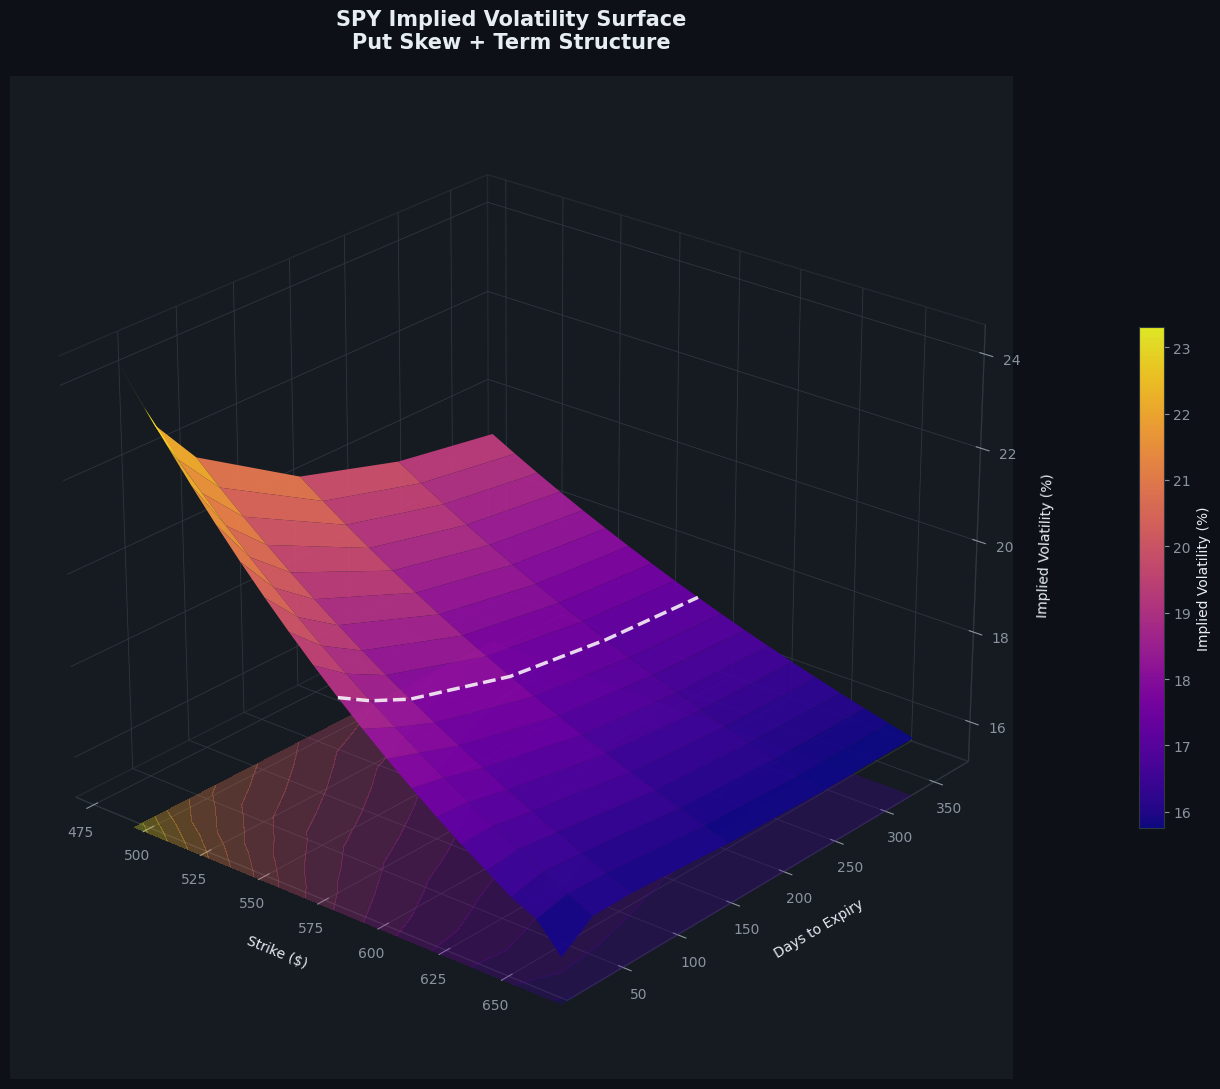

In [9]:
# ── Build surface data ────────────────────────────────────────────────────────
surface_data = chain[chain['iv_call_computed'].notna()].copy()
surface_data = surface_data[(surface_data['moneyness'].between(0.84, 1.16))]

# Pivot
pivot = surface_data.pivot_table(index='days_to_exp', columns='strike',
                                  values='iv_call_computed', aggfunc='mean')
pivot = pivot.interpolate(axis=1).interpolate(axis=0)
pivot = pivot.dropna()

T_surf = pivot.index.values
K_surf = pivot.columns.values
KK, TT = np.meshgrid(K_surf, T_surf)
IV     = pivot.values * 100  # in %

# ── 3D Surface plot ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#0d1117')

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#161b22')

surf = ax.plot_surface(KK, TT, IV, cmap='plasma', alpha=0.92,
                        linewidth=0, antialiased=True,
                        rstride=1, cstride=1)

# Contour projections
offset_z = IV.min() - 1
ax.contourf(KK, TT, IV, zdir='z', offset=offset_z, cmap='plasma', alpha=0.3, levels=15)

# ATM line
atm_iv_by_T = [pivot.loc[t, min(K_surf, key=lambda k: abs(k-S))] * 100
               for t in T_surf if t in pivot.index]
ax.plot([S]*len(T_surf), T_surf, atm_iv_by_T,
        color='white', lw=2.5, linestyle='--', alpha=0.85, zorder=10, label='ATM')

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.08)
cbar.set_label('Implied Volatility (%)', color='#e6edf3', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')

ax.set_xlabel('Strike ($)',          labelpad=10, color='#e6edf3')
ax.set_ylabel('Days to Expiry',      labelpad=10, color='#e6edf3')
ax.set_zlabel('Implied Volatility (%)', labelpad=8, color='#e6edf3')
ax.set_title('SPY Implied Volatility Surface\nPut Skew + Term Structure',
             fontsize=15, fontweight='bold', color='#e6edf3', pad=20)
ax.tick_params(colors='#8b949e')
ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#30363d'); ax.yaxis.pane.set_edgecolor('#30363d')
ax.zaxis.pane.set_edgecolor('#30363d')
ax.grid(True, color='#30363d', alpha=0.5)
ax.view_init(elev=25, azim=-50)

plt.tight_layout()
plt.savefig('charts/05_vol_surface_3d.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

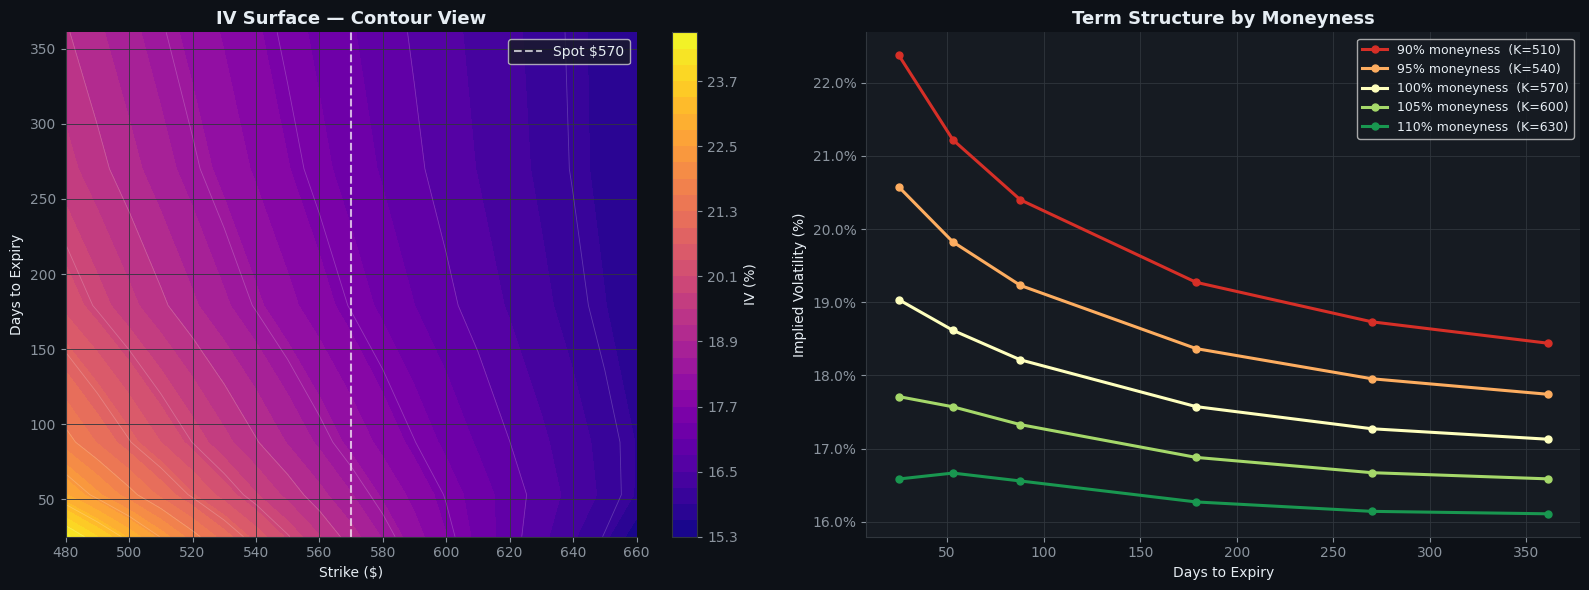

In [10]:
# ── Surface — Top-down contour view ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Heatmap
im = axes[0].contourf(KK, TT, IV, levels=30, cmap='plasma')
axes[0].contour(KK, TT, IV, levels=12, colors='white', alpha=0.2, linewidths=0.6)
axes[0].axvline(S, color='white', lw=1.5, linestyle='--', alpha=0.7, label=f'Spot ${S:.0f}')
plt.colorbar(im, ax=axes[0], label='IV (%)')
axes[0].set_xlabel('Strike ($)'); axes[0].set_ylabel('Days to Expiry')
axes[0].set_title('IV Surface — Contour View')
axes[0].legend()

# Term structure for key moneyness levels
moneyness_levels = [0.90, 0.95, 1.00, 1.05, 1.10]
ts_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(moneyness_levels)))
for m, col in zip(moneyness_levels, ts_colors):
    K_target = min(K_surf, key=lambda k: abs(k/S - m))
    if K_target in pivot.columns:
        iv_ts = pivot[K_target].values * 100
        axes[1].plot(pivot.index, iv_ts, color=col, lw=2.2, marker='o', ms=5,
                     label=f'{m:.0%} moneyness  (K={K_target:.0f})')

axes[1].set_xlabel('Days to Expiry')
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].set_title('Term Structure by Moneyness')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/06_vol_surface_2d.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. Payoff Profiles & Break-Even Analysis

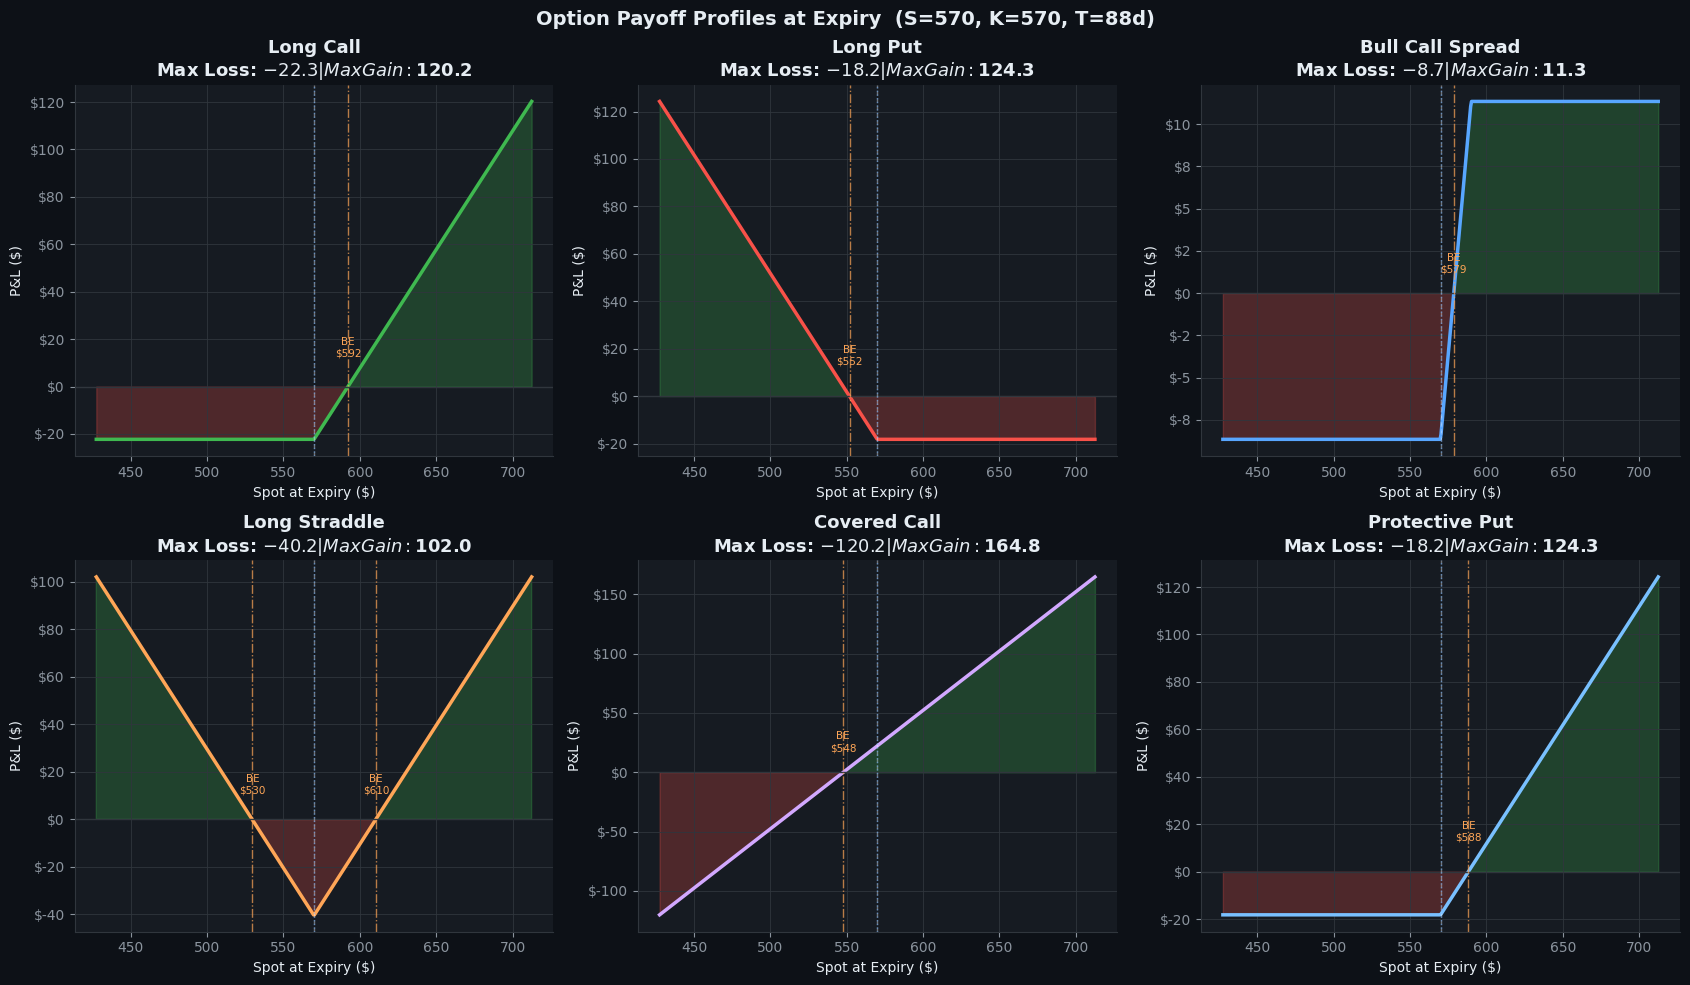

In [11]:
# ── Payoff diagrams for common strategies ─────────────────────────────────────
spots_pnl = np.linspace(S*0.75, S*1.25, 500)

# Prices at inception
K1, K2 = K_atm, K_atm + 20   # strikes for spreads
call_K1 = BlackScholes(S, K1, T_3m, r, q, sigma_atm).call
call_K2 = BlackScholes(S, K2, T_3m, r, q, sigma_atm).call
put_K1  = BlackScholes(S, K1, T_3m, r, q, sigma_atm).put
put_K2  = BlackScholes(S, K2-20, T_3m, r, q, sigma_atm).put   # K2-20 for put spread

# At expiry payoffs
payoffs = {
    'Long Call':      np.maximum(spots_pnl - K1, 0) - call_K1,
    'Long Put':       np.maximum(K1 - spots_pnl, 0) - put_K1,
    'Bull Call Spread': (np.maximum(spots_pnl-K1,0) - call_K1) - (np.maximum(spots_pnl-K2,0) - call_K2),
    'Long Straddle':  np.maximum(spots_pnl-K1,0) + np.maximum(K1-spots_pnl,0) - call_K1 - put_K1,
    'Covered Call':   (spots_pnl - S) + call_K1,   # long stock + short call
    'Protective Put': (spots_pnl - S) - put_K1 + np.maximum(K1-spots_pnl,0),
}
strategy_colors = [C['call'], C['put'], C['neutral'], C['accent'], C['greek'], '#79c0ff']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Option Payoff Profiles at Expiry  (S={S:.0f}, K={K1:.0f}, T={T_3m*365:.0f}d)',
             fontsize=14, fontweight='bold')

for ax, (name, pnl), col in zip(axes.flat, payoffs.items(), strategy_colors):
    ax.fill_between(spots_pnl, pnl, 0,
                    where=pnl>=0, alpha=0.25, color=C['call'])
    ax.fill_between(spots_pnl, pnl, 0,
                    where=pnl<0, alpha=0.25, color=C['put'])
    ax.plot(spots_pnl, pnl, color=col, lw=2.5)
    ax.axhline(0, color='#30363d', lw=1)
    ax.axvline(S,  color='white',      lw=1, linestyle='--', alpha=0.4, label=f'S={S:.0f}')
    ax.axvline(K1, color=C['neutral'], lw=1, linestyle=':',  alpha=0.5, label=f'K={K1:.0f}')
    # Break-even
    sign_changes = np.where(np.diff(np.sign(pnl)))[0]
    for idx in sign_changes:
        be = np.interp(0, [pnl[idx], pnl[idx+1]], [spots_pnl[idx], spots_pnl[idx+1]])
        ax.axvline(be, color=C['accent'], lw=1, linestyle='-.', alpha=0.7)
        ax.annotate(f'BE\n${be:.0f}', xy=(be, ax.get_ylim()[1]*0.1),
                    fontsize=7.5, color=C['accent'], ha='center')
    max_loss = pnl.min()
    max_gain = pnl.max()
    ax.set_title(f'{name}\nMax Loss: ${max_loss:.1f}  |  Max Gain: {"$"+f"{max_gain:.1f}" if max_gain < 999 else "∞"}')
    ax.set_xlabel('Spot at Expiry ($)')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))

plt.tight_layout()
plt.savefig('charts/07_payoff_profiles.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7. Summary Dashboard

In [12]:
# ── Greeks summary table ──────────────────────────────────────────────────────
print("=" * 65)
print("  GREEKS REFERENCE TABLE — SPY ATM Options")
print(f"  Spot={S:.1f}  r={r*100:.2f}%  q={q*100:.2f}%  σ(ATM)={sigma_atm*100:.1f}%")
print("=" * 65)
headers = f"  {'Expiry':12} {'DTE':>5} {'C Price':>9} {'P Price':>9} {'Delta C':>9} {'Gamma':>9} {'Vega':>8} {'Theta C':>9}"
print(headers)
print("-" * 65)
for exp, days in zip(expiry_labels if 'expiry_labels' in dir() else chain['expiry'].unique(),
                     expiry_days   if 'expiry_days'   in dir() else chain.groupby('expiry')['days_to_exp'].first().values):
    T_e = days / 365
    # Get ATM IV for this expiry
    sub = chain[(chain['expiry']==exp)]
    if len(sub) == 0: continue
    atm_row = sub.iloc[(sub['moneyness']-1).abs().argsort()[:1]]
    iv_e = atm_row['iv_call_computed'].values[0] if not np.isnan(atm_row['iv_call_computed'].values[0]) else sigma_atm
    o = BlackScholes(S, K_atm, T_e, r, q, iv_e)
    print(f"  {exp:12} {days:>5} {o.call:>9.3f} {o.put:>9.3f} "
          f"{o.delta_call:>9.4f} {o.gamma:>9.6f} {o.vega:>8.4f} {o.theta_call:>9.4f}")
print("=" * 65)
print("  Vega = $/1% change in σ  |  Theta = $/calendar day  |  Rho = $/1% change in r")

# ── IV skew summary ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  PUT SKEW — 25-Delta Risk Reversal (approx.)")
print(f"  Expiry       25Δ Put IV   ATM IV   25Δ Call IV   Skew")
print("-" * 55)
for exp, days in zip(chain['expiry'].unique(), chain.groupby('expiry')['days_to_exp'].first().values):
    sub = chain[chain['expiry']==exp].dropna(subset=['iv_call_computed'])
    sub = sub[(sub['moneyness']>=0.88) & (sub['moneyness']<=1.12)]
    if len(sub) < 4: continue
    atm_iv  = sub.iloc[(sub['moneyness']-1.00).abs().argsort()].iloc[0]['iv_call_computed']
    otm_put = sub.iloc[(sub['moneyness']-0.95).abs().argsort()].iloc[0]['iv_call_computed']
    otm_cal = sub.iloc[(sub['moneyness']-1.05).abs().argsort()].iloc[0]['iv_call_computed']
    skew = (otm_put - otm_cal) * 100
    print(f"  {exp:12}  {otm_put*100:>7.2f}%   {atm_iv*100:>5.2f}%   {otm_cal*100:>8.2f}%  {skew:>+6.2f}pp")
print("=" * 55)

  GREEKS REFERENCE TABLE — SPY ATM Options
  Spot=570.0  r=4.25%  q=1.30%  σ(ATM)=18.2%
  Expiry         DTE   C Price   P Price   Delta C     Gamma     Vega   Theta C
-----------------------------------------------------------------
  2026-04-17      25    11.890    10.740    0.5256  0.014006   0.5933   -0.2701
  2026-05-15      53    17.309    14.877    0.5372  0.009802   0.8609   -0.1957
  2026-06-19      88    22.271    18.244    0.5477  0.007742   1.1045   -0.1592
  2026-09-18     179    31.848    23.713    0.5674  0.005561   1.5572   -0.1219
  2026-12-18     270    39.513    27.327    0.5819  0.004554   1.8903   -0.1063
  2027-03-19     361    46.286    30.105    0.5935  0.003925   2.1604   -0.0973
  Vega = $/1% change in σ  |  Theta = $/calendar day  |  Rho = $/1% change in r

  PUT SKEW — 25-Delta Risk Reversal (approx.)
  Expiry       25Δ Put IV   ATM IV   25Δ Call IV   Skew
-------------------------------------------------------
  2026-04-17      20.58%   19.04%      17.71%  

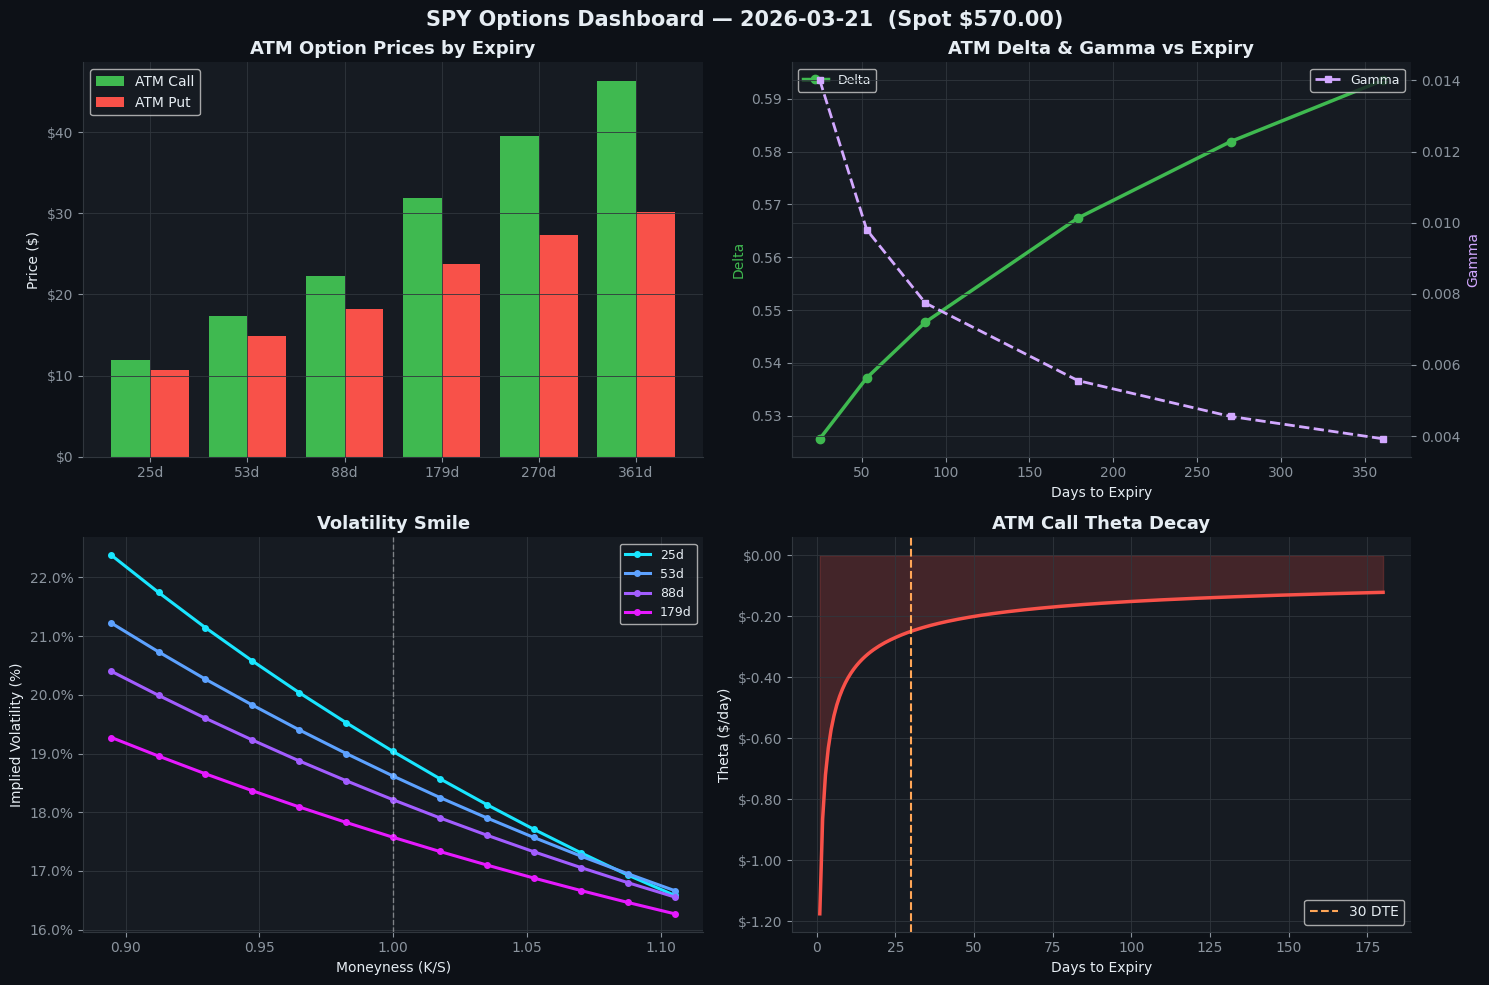


✅ All charts saved in charts/


In [13]:
# ── Final summary chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'SPY Options Dashboard — {snap["date"]}  (Spot ${S:.2f})',
             fontsize=15, fontweight='bold')

# 1. ATM price by expiry (call vs put)
atm_data = []
exps_short = []
for exp, days in zip(chain['expiry'].unique(), chain.groupby('expiry')['days_to_exp'].first().values):
    sub = chain[chain['expiry']==exp]
    row = sub.iloc[(sub['moneyness']-1).abs().argsort()].iloc[0]
    atm_data.append((days, row['call_mid'], row['put_mid']))
    exps_short.append(f"{days}d")
atm_arr = np.array(atm_data)
axes[0,0].bar(np.arange(len(exps_short))-0.2, atm_arr[:,1], 0.4, color=C['call'], label='ATM Call')
axes[0,0].bar(np.arange(len(exps_short))+0.2, atm_arr[:,2], 0.4, color=C['put'],  label='ATM Put')
axes[0,0].set_xticks(range(len(exps_short))); axes[0,0].set_xticklabels(exps_short)
axes[0,0].set_title('ATM Option Prices by Expiry'); axes[0,0].set_ylabel('Price ($)')
axes[0,0].yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
axes[0,0].legend()

# 2. Delta term structure
deltas, thetas, gammas = [], [], []
for days, cp, pp in atm_data:
    T_e = days/365
    sub = chain[(chain['expiry']==chain['expiry'].unique()[list(atm_arr[:,0]).index(days)])]
    row = sub.iloc[(sub['moneyness']-1).abs().argsort()].iloc[0]
    iv_e = row['iv_call_computed'] if not np.isnan(row['iv_call_computed']) else sigma_atm
    o = BlackScholes(S, K_atm, T_e, r, q, iv_e)
    deltas.append(o.delta_call); thetas.append(o.theta_call); gammas.append(o.gamma)
axes[0,1].plot(list(atm_arr[:,0]), deltas, color=C['call'], lw=2.5, marker='o', ms=6, label='Delta')
ax2 = axes[0,1].twinx()
ax2.plot(list(atm_arr[:,0]), gammas, color=C['greek'], lw=2, marker='s', ms=5, linestyle='--', label='Gamma')
ax2.set_ylabel('Gamma', color=C['greek'])
axes[0,1].set_xlabel('Days to Expiry'); axes[0,1].set_ylabel('Delta', color=C['call'])
axes[0,1].set_title('ATM Delta & Gamma vs Expiry')
axes[0,1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

# 3. IV smile for 3 expiries
exps_plot = list(chain['expiry'].unique())[:4]
for exp, col in zip(exps_plot, plt.cm.cool(np.linspace(0.1,0.9,4))):
    sub = chain[(chain['expiry']==exp) & chain['iv_call_computed'].notna()]
    sub = sub[(sub['moneyness']>=0.88) & (sub['moneyness']<=1.12)]
    axes[1,0].plot(sub['moneyness'], sub['iv_call_computed']*100, color=col, lw=2.2,
                   marker='o', ms=4, label=f"{sub['days_to_exp'].iloc[0]}d")
axes[1,0].axvline(1.0, color='white', lw=1, linestyle='--', alpha=0.4)
axes[1,0].set_title('Volatility Smile'); axes[1,0].set_xlabel('Moneyness (K/S)')
axes[1,0].set_ylabel('Implied Volatility (%)')
axes[1,0].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
axes[1,0].legend(fontsize=9)

# 4. Theta decay for ATM
times_plot = np.linspace(1/365, 180/365, 200)
sigmas_by_T = []
for t in times_plot:
    # Interpolate ATM IV by time
    days_arr = list(atm_arr[:,0])
    iv_arr   = [chain[(chain['expiry']==exp)].iloc[(chain[(chain['expiry']==exp)]['moneyness']-1).abs().argsort()].iloc[0]['iv_call_computed']
                for exp in chain['expiry'].unique()]
    iv_interp = np.interp(t*365, days_arr, iv_arr)
    sigmas_by_T.append(iv_interp if not np.isnan(iv_interp) else sigma_atm)

thetas_t = [BlackScholes(S, K_atm, t, r, q, s).theta_call
             for t, s in zip(times_plot, sigmas_by_T)]
axes[1,1].plot(times_plot*365, thetas_t, color=C['put'], lw=2.5)
axes[1,1].fill_between(times_plot*365, thetas_t, 0, alpha=0.2, color=C['put'])
axes[1,1].axvline(30, color=C['accent'], lw=1.5, linestyle='--', label='30 DTE')
axes[1,1].set_title('ATM Call Theta Decay'); axes[1,1].set_xlabel('Days to Expiry')
axes[1,1].set_ylabel('Theta ($/day)')
axes[1,1].yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2f'))
axes[1,1].legend()

plt.tight_layout()
plt.savefig('charts/08_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n✅ All charts saved in charts/')